# Ultimate Attribute Opening Examples

This notebook demonstrates direct Ultimate Attribute Opening (UAO) workflows with `mmcfilters`.


In [1]:
import mmcfilters
import math
from pathlib import Path

import cv2 as cv
from IPython import display
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (16, 16)


def load_grayscale(path):
    image = cv.imread(str(path), cv.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return np.ascontiguousarray(image, dtype=np.uint8)


def create_component_tree(image, is_maxtree, radius=1.5):
    if is_maxtree:
        return mmcfilters.MorphologicalTreeFactory.create_max_tree(image, radius=radius)
    return mmcfilters.MorphologicalTreeFactory.create_min_tree(image, radius=radius)


## Load the input image

The examples use a grayscale image so max-tree attributes can be interpreted directly against image intensity and component geometry.


In [2]:
#input_image = load_grayscale("../dat/imgTeste.png")
input_image = load_grayscale("../dat/imgObjetos.png")
#input_image = load_grayscale("../dat/cable.png")

(num_rows, num_columns) = input_image.shape

#plt.imshow(input_image, cmap='gray', vmax=255, vmin=0)
#plt.title('input')

In [3]:
tree = mmcfilters.MorphologicalTreeFactory.create_max_tree(input_image, radius=1.5)
attribute_indices, attribute_matrix = mmcfilters.Attribute.compute_topology_attributes(tree, [mmcfilters.Attribute.BOUNDING_BOX_HEIGHT])
node_attribute = attribute_matrix[:, attribute_indices['BOUNDING_BOX_HEIGHT']]
attribute_filter = mmcfilters.AttributeFilters(tree)


Text(0.5, 1.0, 'attribute filter')

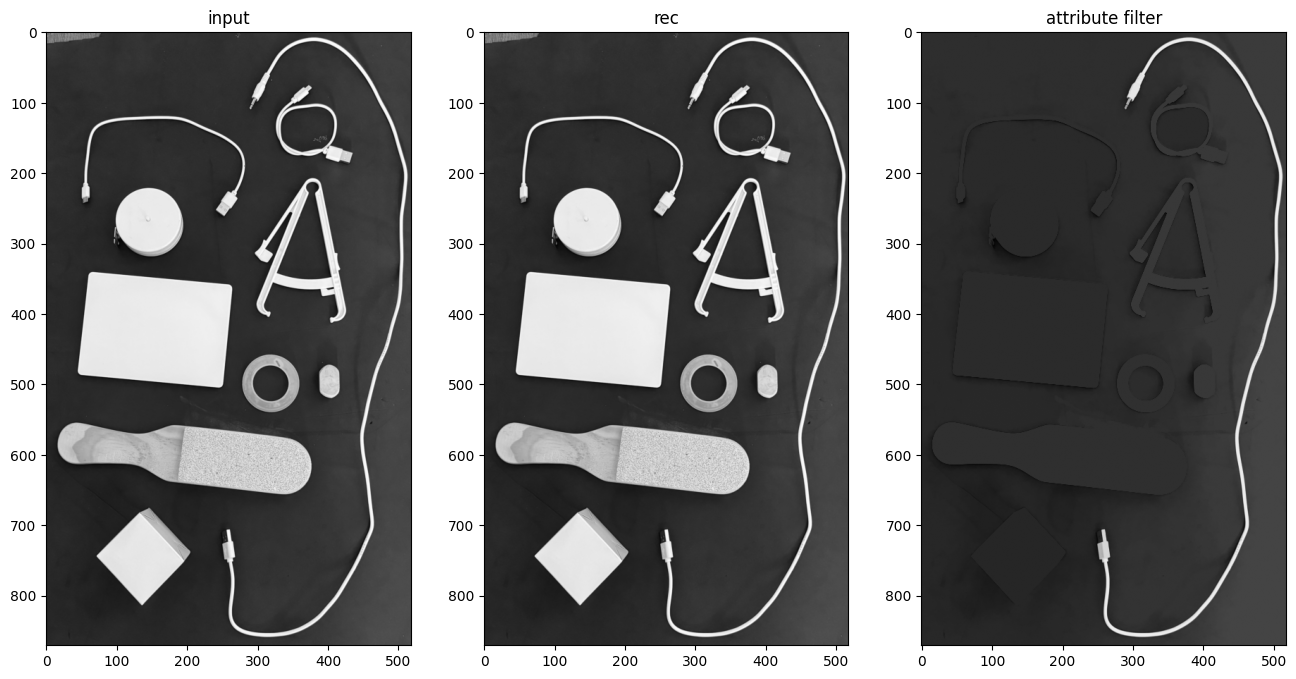

In [4]:
reconstructed_image = tree.reconstruct_from_node_altitudes() 
preservation_mask = mmcfilters.NodePreservationMask((node_attribute > 500).tolist())
filtered_image = mmcfilters.HardSubtractiveAttributeFilter(tree).apply_hard_subtractive_attribute_filter(preservation_mask)

plt.subplot(1,3, 1)
plt.imshow(input_image, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,3, 2)
plt.imshow(reconstructed_image.reshape(num_rows, num_columns), cmap='gray', vmax=255, vmin=0)
plt.title('rec')

plt.subplot(1,3, 3)
plt.imshow(filtered_image.reshape(num_rows, num_columns), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')


#np.sum(input_image.ravel() - reconstructed_image)

## Execute UAO directly

`UltimateAttributeOpening` computes the contrast and associated images directly for the selected decision rule.


Text(0.5, 1.0, 'associated')

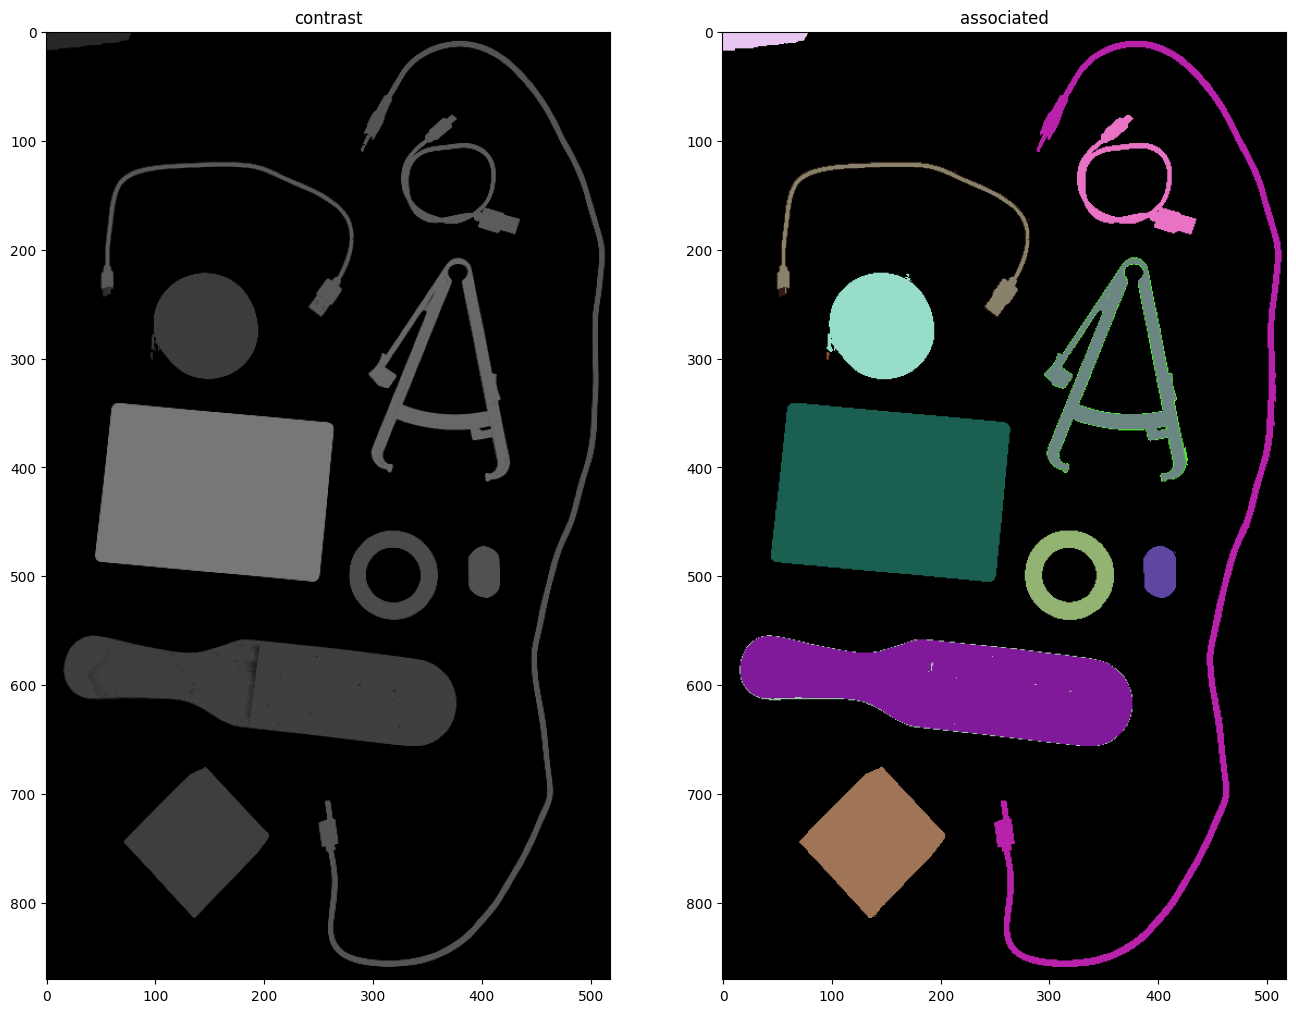

In [5]:
altitude_window_radius = 19
uao = mmcfilters.UltimateAttributeOpening(tree, node_attribute)
uao.execute_with_mser(num_rows, altitude_window_radius)
roundtrip_contrast_image = uao.get_max_contrast_image()
roundtrip_associated_color_image = uao.get_associated_colored_image()

plt.subplot(1,2,1)
plt.imshow(roundtrip_contrast_image.reshape(num_rows, num_columns), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(roundtrip_associated_color_image.reshape(num_rows, num_columns, 3), vmax=255, vmin=0)
plt.title('associated')

Text(0.5, 1.0, 'associated')

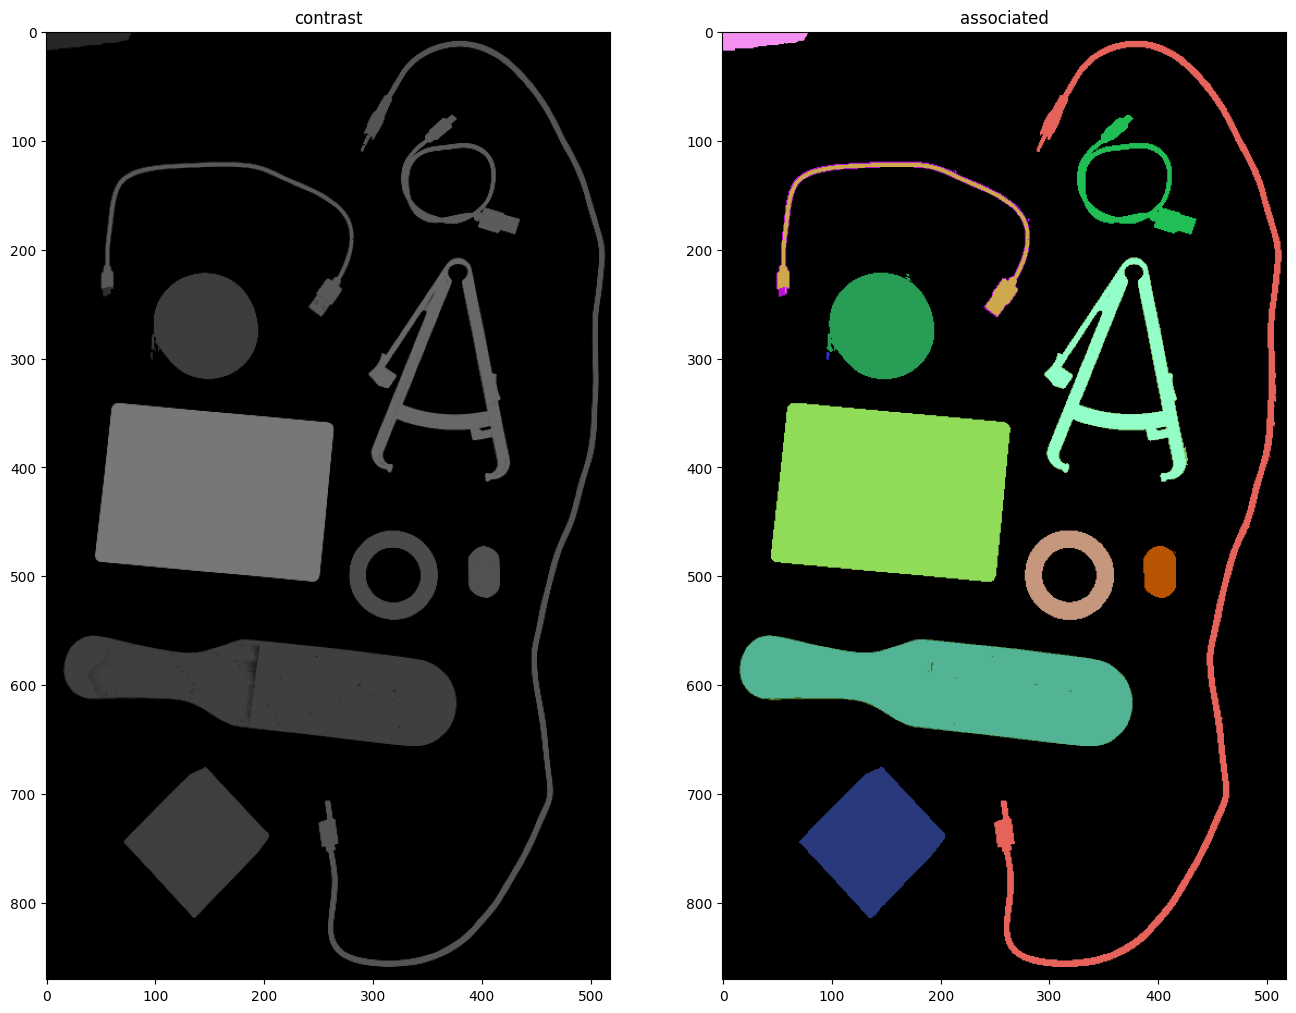

In [6]:
altitude_window_radius = 19
uao = mmcfilters.UltimateAttributeOpening(tree, node_attribute)

uao.execute_with_mser( num_rows, altitude_window_radius )
associated_image = uao.get_associated_colored_image()
contrast_image = uao.get_max_contrast_image()

#import random
#colors = [ [random.randint(0, 255) for _ in range(3)] for _ in range(0, np.max(associated_image)+1)]
#rgb_contrast_image = [(0,0,0) if p == 0 else colors[p] for p in associated_image]

plt.subplot(1,2,1)
plt.imshow(contrast_image.reshape(num_rows, num_columns), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(np.array(associated_image).reshape(num_rows, num_columns, 3), vmax=255, vmin=0)
plt.title('associated')

In [7]:
np.sum(roundtrip_contrast_image - contrast_image)

np.uint64(0)

## Repeat the workflow on a second image

The same steps are repeated on another input to check that the chosen parameters and attribute decision rule generalize beyond the first example.


Text(0.5, 1.0, 'associated')

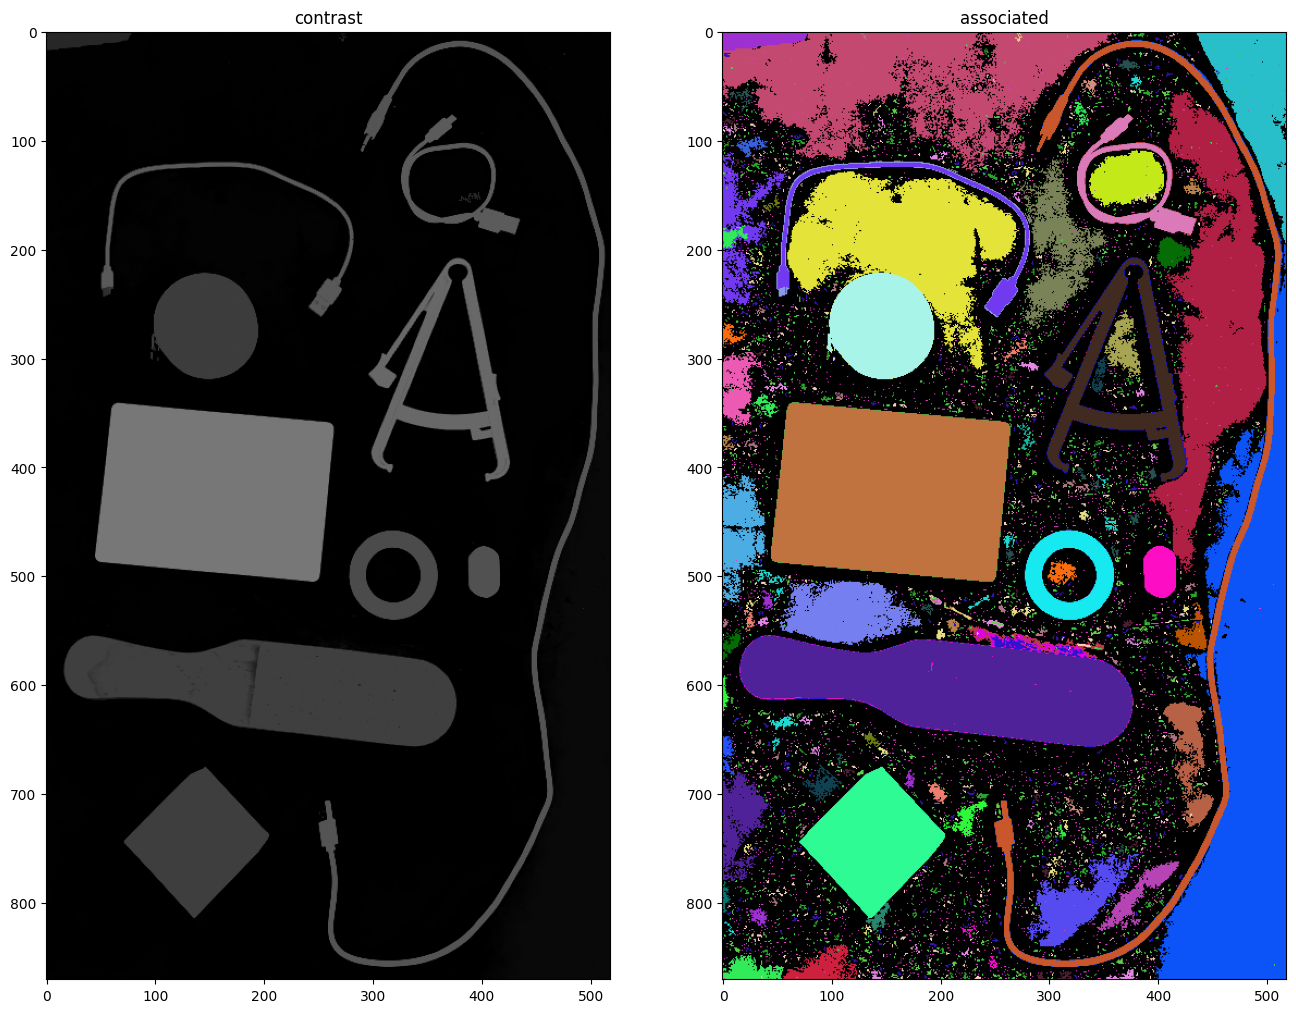

In [8]:
input_image = load_grayscale("../dat/imgObjetos.png")
(num_rows, num_columns) = input_image.shape
tree = mmcfilters.MorphologicalTreeFactory.create_max_tree(input_image, radius=1.5)
attribute_indices, attribute_matrix = mmcfilters.Attribute.compute_topology_attributes(tree, [mmcfilters.Attribute.BOUNDING_BOX_HEIGHT])

uao = mmcfilters.UltimateAttributeOpening(tree, attribute_matrix[:, attribute_indices['BOUNDING_BOX_HEIGHT']])
uao.execute(num_rows - 1)
contrast_image = uao.get_max_contrast_image()
associated_color_image = uao.get_associated_colored_image()

plt.subplot(1,2,1)
plt.imshow(contrast_image.reshape(num_rows, num_columns), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(associated_color_image.reshape(num_rows, num_columns, 3), vmax=255, vmin=0)
plt.title('associated')

Text(0.5, 1.0, 'associated')

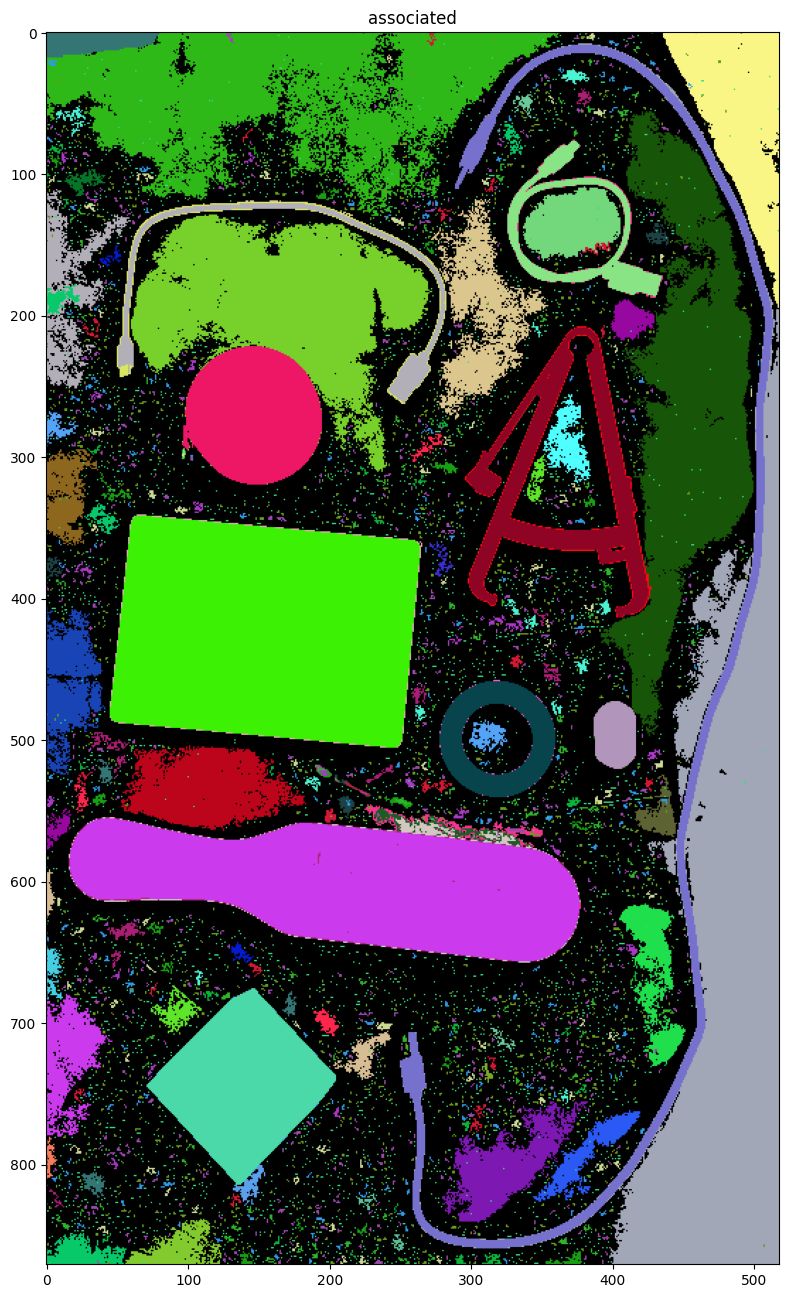

In [9]:
associated_image = uao.get_associated_image().ravel()

import random
colors = [[random.randint(0, 255) for _ in range(3)] for _ in range(0, int(np.max(associated_image)) + 1)]
rgb_contrast_image = [(0, 0, 0) if p == 0 else colors[int(p)] for p in associated_image]

plt.imshow(np.array(rgb_contrast_image).reshape(num_rows, num_columns, 3), vmax=255, vmin=0)
plt.title('associated')

Text(0.5, 1.0, 'associated')

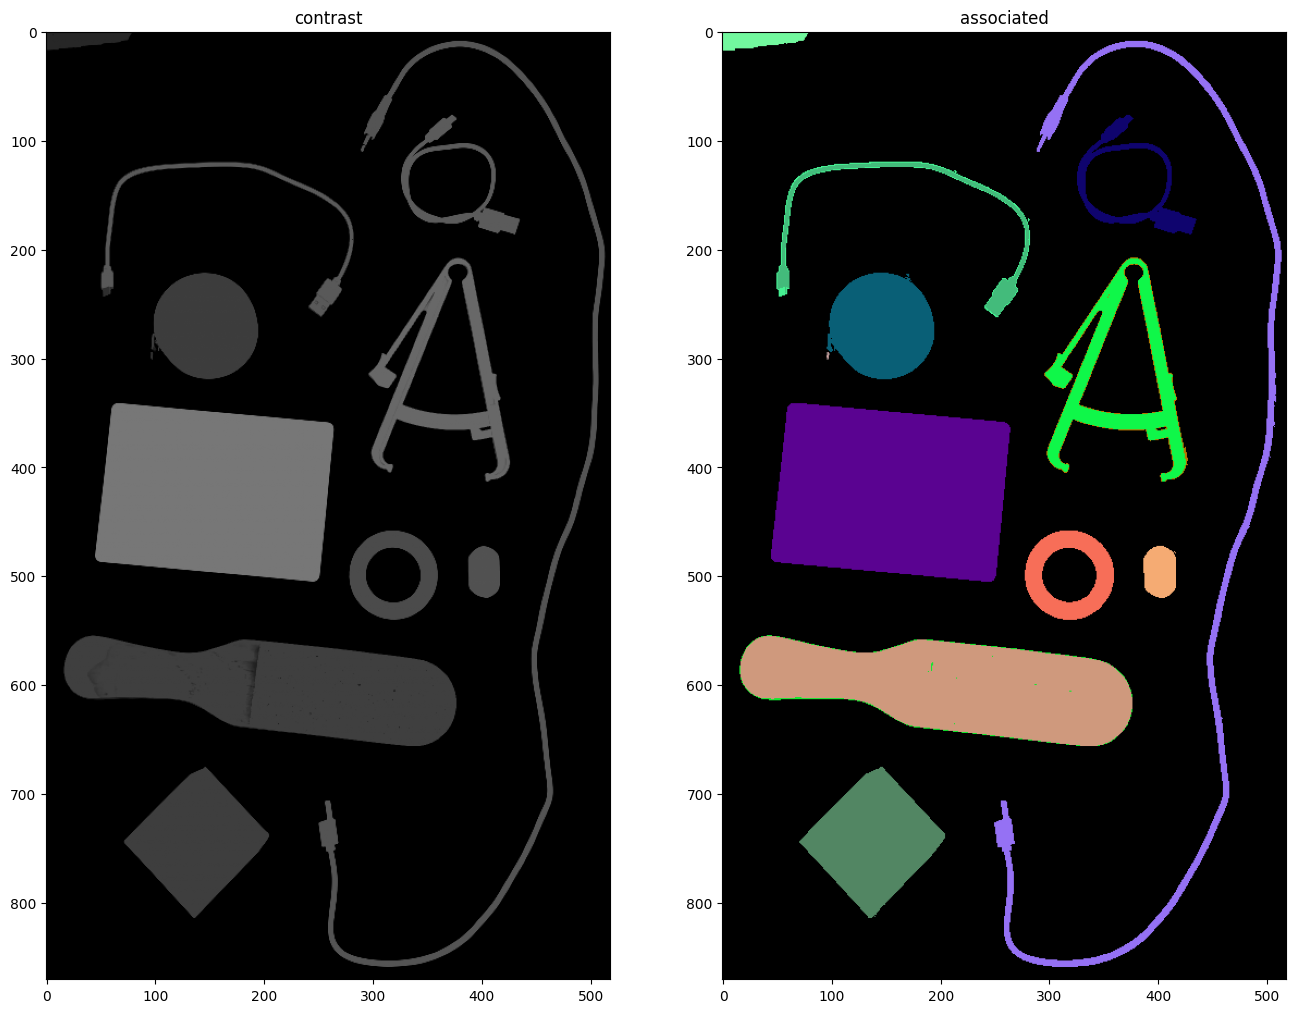

In [10]:
maximum_attribute_threshold = num_rows
altitude_window_radius = 20

uao.execute_with_mser( int(maximum_attribute_threshold), altitude_window_radius )
contrast_image = uao.get_max_contrast_image()
associated_color_image = uao.get_associated_colored_image()

plt.subplot(1,2,1)
plt.imshow(contrast_image.reshape(num_rows, num_columns), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(associated_color_image.reshape(num_rows, num_columns, 3), vmax=255, vmin=0)
plt.title('associated')

In [11]:
np.min(associated_color_image), np.max(associated_color_image)

(np.uint8(0), np.uint8(248))

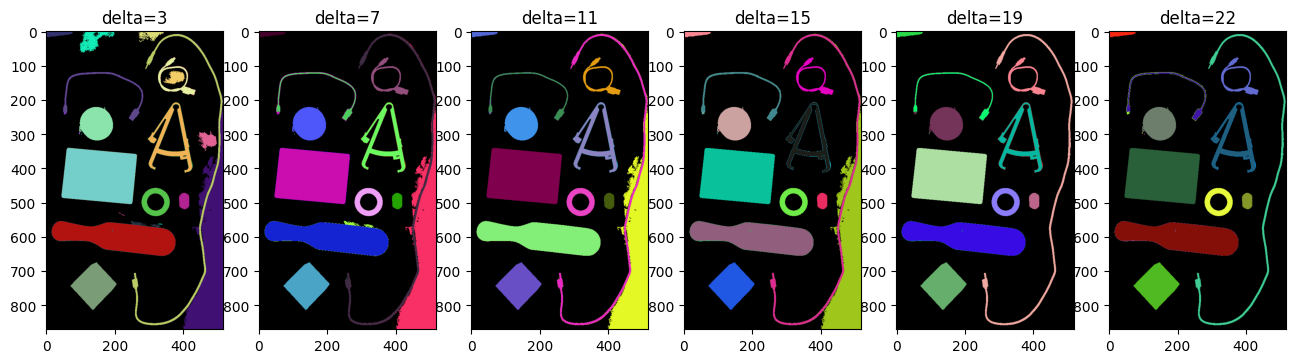

In [12]:
uao = mmcfilters.UltimateAttributeOpening(tree, attribute_matrix[:,attribute_indices['BOUNDING_BOX_HEIGHT']])
maximum_attribute_threshold = num_rows
line = 1
for i in range(1, 6+1):
    altitude_window_radius = int(i*3.8)
    uao.execute_with_mser( int(maximum_attribute_threshold), altitude_window_radius )
    associated_color_image = uao.get_associated_colored_image()
        
    plt.subplot(line,6, i)
    plt.imshow(associated_color_image.reshape(num_rows, num_columns, 3), vmax=255, vmin=0)
    plt.title('radius=' + str(altitude_window_radius))